In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt

In [2]:
import requests
import pandas as pd

url = 'http://127.0.0.1:8000/'
headers = {
'accept': 'application/json',
'Content-Type': 'application/json'}
response = requests.get('http://127.0.0.1:8000/analyses_UV/', headers=headers)


In [3]:
pd.DataFrame([pd.Series(a['Analyses_UV_data'],name=a['Analyse_UV_name']) for a in response.json()]).T.plot(legend=False)

TypeError: string indices must be integers, not 'str'

In [140]:
data = pd.DataFrame([pd.Series(a['Analyses_UV_data'],name=a['Analyse_UV_name']) for a in response.json()])

In [141]:
response = requests.get('http://127.0.0.1:8000/OGD/', headers=headers)


In [148]:
metadata = pd.DataFrame(response.json())
metadata.columns

time_columns = ['Batch_OGD_date','Batch_OGD_heure_debut','Batch_OGD_heure_fin']
categorical_columns = ['Batch_OGD_Technicien','Batch_OGD_KC8_batch','Batch_OGD_THF_batch']
numerical_columns = ['Batch_OGD_KC8_masse','Batch_OGD_Temperature','Batch_OGD_Agitation','Batch_OGD_room_HR','Batch_OGD_room_T']

In [136]:
# save data for python script for ml flow on azure

import pickle
with open('ML_Models/data/train.pkl', 'wb') as file: 
    pickle.dump(metadata.iloc[:120,2:], file) 
with open("ML_Models/data/test.pkl", 'wb') as file: 
    pickle.dump(metadata.iloc[40:,2:], file) 


In [150]:
# handeling time variables

timed = metadata[time_columns]
for col in timed.columns:
    timed.loc[:,col] = pd.to_datetime(timed[col])

timed['year'] = pd.DatetimeIndex(timed['Batch_OGD_date']).year.astype(str)
timed['month'] = pd.DatetimeIndex(timed['Batch_OGD_date']).month.astype(str)
timed['time_exfo'] = (timed['Batch_OGD_heure_fin'] - timed['Batch_OGD_heure_debut']) / pd.Timedelta(hours=1)

metadata_timed = pd.concat([metadata,timed],axis=1)

numerical_columns = numerical_columns + ['time_exfo']
categorical_columns = categorical_columns + ['year','month']


/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_18406/2575082292.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timed['year'] = pd.DatetimeIndex(timed['Batch_OGD_date']).year.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_18406/2575082292.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  timed['month'] = pd.DatetimeIndex(timed['Batch_OGD_date']).month.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_18406/2575082292.py:9: SettingWithCopyWarning

In [151]:
# handeling numerical variables
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled = scaler.fit_transform(metadata_timed[numerical_columns])
scaled = pd.DataFrame(scaled)
scaled.columns = numerical_columns


In [153]:
# handeling categorical variables
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder( sparse_output=False)
ohe_data = ohe.fit_transform(metadata_timed[categorical_columns])
ohe_cols = [a for b in ohe.categories_ for a in b]
onehotencoded = pd.DataFrame(data=ohe_data,columns=ohe_cols)
# onehotencoded = pd.get_dummies(metadata_timed[categorical_columns],drop_first=True).reset_index(drop=True)

In [154]:
metadata_ready = pd.concat([metadata['Batch_OGD_name'],scaled,onehotencoded],axis=1)
metadata_ready

,Batch_OGD_name,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,LB,LC,RS,...,11,12,2,3,4,5,6,7,8,9
0,OGD2415D,0.0,-1.285104,-1.176620,-1.379592,-0.060405,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,OGD2307D,0.0,1.208610,-0.122834,-1.051788,1.170353,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,OGD2353D,0.0,-0.038247,1.282214,1.242840,-0.060405,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,OGD2323B,0.0,-1.285104,-1.176620,-1.379592,1.170353,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,OGD2334C,0.0,1.208610,1.282214,-1.707396,-0.060405,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,OGD2326C,0.0,1.208610,-0.122834,-1.051788,1.170353,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
159,OGD2313B,0.0,1.208610,-0.122834,0.587232,-0.060405,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
160,OGD2311A,0.0,-1.285104,-0.122834,-1.379592,-0.060405,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
161,OGD2437D,0.0,-1.285104,-1.176620,-0.723984,-1.291164,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [95]:
# make sample

sample_name = 'OGD2446A'
response = requests.get(f'http://127.0.0.1:8000/OGD/name/{sample_name}', headers=headers)
sample = pd.DataFrame(response.json(),index=[0])


sample_timed = sample[time_columns]
for col in time_columns:
    sample_timed.loc[:,col] = pd.to_datetime(sample_timed[col])

sample_timed['year'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).year.astype(str)
sample_timed['month'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).month.astype(str)
sample_timed['time_exfo'] = (sample_timed['Batch_OGD_heure_fin'] - sample_timed['Batch_OGD_heure_debut']) / pd.Timedelta(hours=1)

sample_metadata_timed = pd.concat([sample,sample_timed],axis=1)

sample_scaled = scaler.transform(sample_metadata_timed[numerical_columns])
sample_scaled = pd.DataFrame(scaled, columns=numerical_columns,index=[0])

sample_ohe_data = ohe.transform(sample_metadata_timed[categorical_columns])
sample_onehotencoded = pd.DataFrame(data=sample_ohe_data,columns=ohe_cols,index=[0])

sample_metadata_ready = pd.concat([sample['Batch_OGD_name'],sample_scaled,sample_onehotencoded],axis=1)
sample_metadata_ready

/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_18406/3870128152.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_timed['year'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).year.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_18406/3870128152.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample_timed['month'] = pd.DatetimeIndex(sample_timed['Batch_OGD_date']).month.astype(str)
/var/folders/dv/gzhyqctn53s9bh23g7tbvl940000gn/T/ipykernel_18406/387012815

,Batch_OGD_name,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,LB,LC,RS,...,11,12,2,3,4,5,6,7,8,9
0,OGD2446A,0.0,-1.285104,-1.17662,-1.379592,-0.060405,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [114]:
metadata_ready.iloc[:120,1:]
metadata_ready.iloc[40:,1:]

,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,LB,LC,RS,TB,...,11,12,2,3,4,5,6,7,8,9
0,0.0,-1.285104,-1.176620,-1.379592,-0.060405,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.208610,-0.122834,-1.051788,1.170353,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,-0.038247,1.282214,1.242840,-0.060405,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,-1.285104,-1.176620,-1.379592,1.170353,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,1.208610,1.282214,-1.707396,-0.060405,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158,0.0,1.208610,-0.122834,-1.051788,1.170353,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
159,0.0,1.208610,-0.122834,0.587232,-0.060405,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
160,0.0,-1.285104,-0.122834,-1.379592,-0.060405,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
161,0.0,-1.285104,-1.176620,-0.723984,-1.291164,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


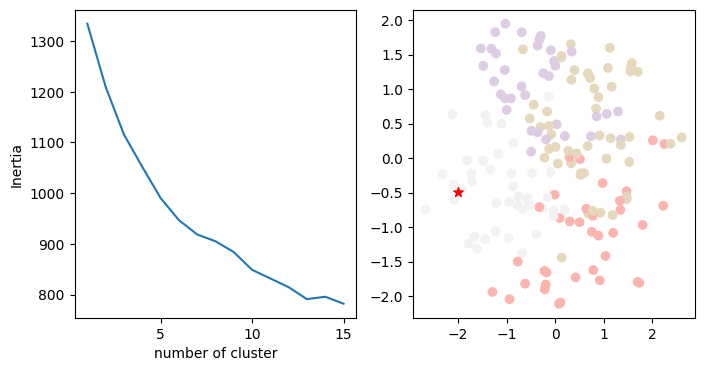

In [99]:
from sklearn.cluster import KMeans
import numpy as np

import numpy as np
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
weights=pca.fit_transform(metadata_ready.iloc[:,1:].fillna(0))
sample_weights = pca.transform(sample_metadata_ready.iloc[:,1:])
inertias=list()
for i in range(1,16):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(metadata_ready.iloc[:,1:].fillna(0))
    inertias.append(kmeans.inertia_)

kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(metadata_ready.iloc[:,1:].fillna(0))


f, ax = plt.subplots(1,2,figsize=(8,4))
ax[0].plot(range(1,16),inertias)
ax[0].set_xlabel("number of cluster")
ax[0].set_ylabel("Inertia")
ax[1].scatter(weights[:,0],weights[:,1],c=kmeans.labels_,cmap='Pastel1')
ax[1].scatter(sample_weights[:,0],sample_weights[:,1],c='red',s=50,marker='*')

In [82]:
metadata_ready.Batch_OGD_name[weights[:,0] > 5]

163    OGD2504A
164     OGD2505
165     OGD2506
Name: Batch_OGD_name, dtype: object

In [80]:
metadata_ready.Batch_OGD_name

,Batch_OGD_name,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,FB,JP,LB,...,11,12,2,3,4,5,6,7,8,9
0,OGD2415D,-0.085729,-1.254850,-1.176365,-0.832628,-0.137110,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,OGD2307D,-0.085729,1.224973,-0.115079,-0.610868,-0.106844,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,OGD2353D,-0.085729,-0.014939,1.299969,0.941451,-0.137110,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,OGD2323B,-0.085729,-1.254850,-1.176365,-0.832628,-0.106844,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,OGD2334C,-0.085729,1.224973,1.299969,-1.054388,-0.137110,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
161,OGD2437D,-0.085729,-1.254850,-1.176365,-0.389108,-0.167376,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
162,OGD2446A,-0.085729,1.224973,1.299969,1.163211,-0.106844,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
163,OGD2504A,0.581352,-1.254850,-0.468841,-5.469628,7.368926,-9.028185,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
164,OGD2505,0.581352,-1.254850,-0.468841,-5.469628,7.368926,-9.027285,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [34]:
import numpy as np
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
weights=pca.fit_transform(data)
data_UV = pd.DataFrame(weights,columns=[f"PC_{i+1}" for i in range(5)])
data_UV_ready = pd.concat([pd.Series(data.index, name='Batch_OGD_name'),data_UV], axis=1)

In [35]:
data_ready = pd.merge(metadata_ready,data_UV_ready,on='Batch_OGD_name')
data_ready

,Batch_OGD_name,Batch_OGD_KC8_masse,Batch_OGD_Temperature,Batch_OGD_Agitation,Batch_OGD_room_HR,Batch_OGD_room_T,time_exfo,FB,JP,LB,...,5,6,7,8,9,PC_1,PC_2,PC_3,PC_4,PC_5
0,OGD2415D,-0.085729,-1.254850,-1.176365,-0.832628,-0.137110,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.050305,0.016194,0.004158,0.013735,-0.006711
1,OGD2415D,-0.085729,-1.254850,-1.176365,-0.832628,-0.137110,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.038402,0.005124,0.031966,0.018759,0.009579
2,OGD2415D,-0.085729,-1.254850,-1.176365,-0.832628,-0.137110,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.033735,0.005932,0.012005,-0.003755,0.004949
3,OGD2415D,-0.085729,-1.254850,-1.176365,-0.832628,-0.137110,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.005864,0.026418,0.028545,-0.007151,-0.009869
4,OGD2415D,-0.085729,-1.254850,-1.176365,-0.832628,-0.137110,0.110770,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.030995,-0.003701,-0.012426,0.007446,0.028630
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
473,OGD2437D,-0.085729,-1.254850,-1.176365,-0.389108,-0.167376,0.110770,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,-0.034725,0.001315,-0.003327,-0.013631,0.004385
474,OGD2446A,-0.085729,1.224973,1.299969,1.163211,-0.106844,0.110770,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.058558,0.012030,-0.032791,-0.012975,-0.010040
475,OGD2446A,-0.085729,1.224973,1.299969,1.163211,-0.106844,0.110770,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.000017,0.014539,-0.009061,-0.010405,0.004624
476,OGD2504A,0.581352,-1.254850,-0.468841,-5.469628,7.368926,-9.028185,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,-0.036971,0.003049,0.023176,0.017665,0.014001


Text(0, 0.5, 'Inertia')

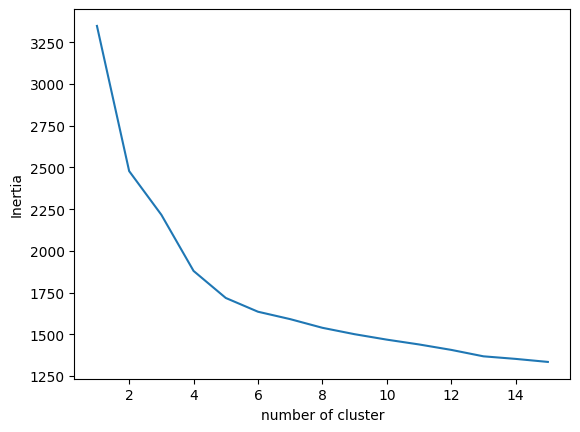

In [36]:
from sklearn.cluster import KMeans
import numpy as np

inertias=list()
for i in range(1,16):
    kmeans = KMeans(n_clusters=i, random_state=0, n_init="auto").fit(data_ready.iloc[:,1:])
    inertias.append(kmeans.inertia_)


plt.plot(range(1,16),inertias)
plt.xlabel("number of cluster")
plt.ylabel("Inertia")

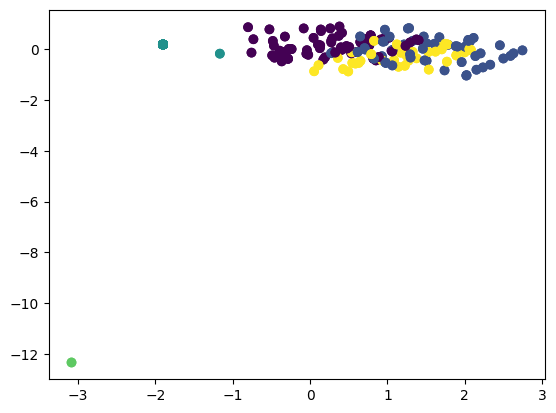

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit(data_ready.iloc[:,1:])
pca = PCA(n_components=5)
w=pca.fit_transform(data_ready.iloc[:,1:])
plt.scatter(w[:,0],w[:,1],c=kmeans.labels_, cmap='viridis')

In [38]:
import numpy as np
from sklearn.decomposition import PCA
pca = PCA(n_components=5)
w=pca.fit_transform(data)
print(pca.explained_variance_ratio_)
print(pca.singular_values_)
import joblib
joblib.dump(pca, "save_on_cloud_pca.joblib")

[0.65240961 0.15432603 0.09543633 0.04501922 0.03677362]
[1.27163746 0.61847583 0.48636242 0.33404281 0.3019057 ]


['save_on_cloud_pca.joblib']

In [39]:
from sklearn.cluster import KMeans
import numpy as np
import random


kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(data)

joblib.dump(kmeans.labels_, "save_on_cloud_kmean_label.joblib")

test = (make_curve().reshape(1, -1))
p=kmeans.predict(test)
c=pca.transform(test)
kmeans.cluster_centers_

NameError: name 'make_curve' is not defined

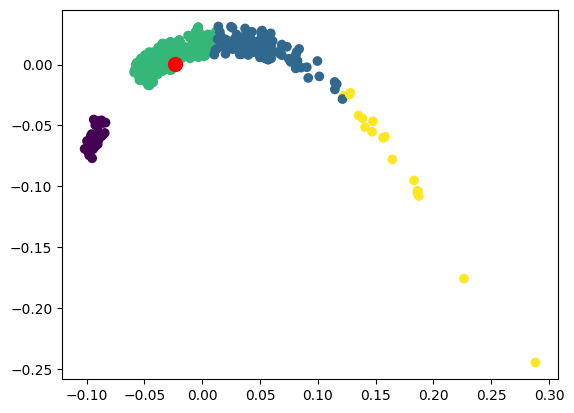

In [69]:
import matplotlib.pyplot as plt
# plt.plot(pca.explained_variance_ratio_.cumsum())
plt.scatter(w[:,0],w[:,1],c=kmeans.labels_)
plt.scatter(c[:,0],c[:,1],c='red',s=100)


In [70]:
from scipy import stats 
import matplotlib.pyplot as plt

def make_curve():
    # Generate the data
    array1 = stats.norm.pdf(range(10, 40), random.choice(np.arange(10,12,0.2)), random.choice(np.arange(2,3,0.1)))
    array2 = stats.norm.pdf(range(30), 10, random.choice(np.arange(2,5,0.2)))

    # Reshape the arrays to 2D (add an extra axis)
    array1 = array1.reshape(1, -1)  # Shape: (1, n)
    array2 = array2.reshape(1, -1)  # Shape: (1, n)

    # Concatenate along axis=1
    result = np.concatenate([array1, array2]).T
    return result.mean(axis=1)